<a href="https://colab.research.google.com/github/Arun-Kalura/BRAIN-TUMOUR-DETECTION-USING-IMAGE-SEGMENTATION/blob/main/tumour_detection_using_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
DATA_PATH = path + "/kaggle_3m"
print(DATA_PATH)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
/kaggle/input/lgg-mri-segmentation/kaggle_3m


In [ ]:
import os
import numpy as np
import cv2

IMAGE_SIZE = 128

images = []
masks = []

for folder in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if "mask" in file:
            mask_path = os.path.join(folder_path, file)
            img_path = mask_path.replace("_mask", "")

            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, 0)  # grayscale

            if img is None or mask is None:
                continue

            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))

            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks) / 255.0

print(images.shape, masks.shape)

(3929, 128, 128, 3) (3929, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, Model

def build_unet(input_shape=(128,128,3)):
    inputs = layers.Input(input_shape)

    # ===== Encoder  =====
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    p3 = layers.MaxPooling2D()(c3)

    # ===== Bottleneck =====
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)

    # ===== Decoder =====
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u3)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

In [ ]:
model = build_unet()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    images, masks,
    validation_split=0.2,
    epochs=10,
    batch_size=16
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 384)              │            │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    442,496 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 64, 64,    │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 192)              │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 128, 128,  │          0 │ conv2d_21[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128, 128,  │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 96)               │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_8[0]

 Total params: 969,281 (3.70 MB)

 Trainable params: 969,281 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 33s 103ms/step - accuracy: 0.9879 - loss: 0.0505 - val_accuracy: 0.9868 - val_loss: 0.0316
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9911 - loss: 0.0253 - val_accuracy: 0.9908 - val_loss: 0.0265
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9931 - loss: 0.0203 - val_accuracy: 0.9920 - val_loss: 0.0221
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9936 - loss: 0.0183 - val_accuracy: 0.9923 - val_loss: 0.0197
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9939 - loss: 0.0161 - val_accuracy: 0.9928 - val_loss: 0.0195
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9944 - loss: 0.0139 - val_accuracy: 0.9923 - val_loss: 0.0186
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9951 - loss: 0.0118 - val_accuracy: 0.9933 - val_loss: 0.0178
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9955 - loss: 0.0105 - val

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


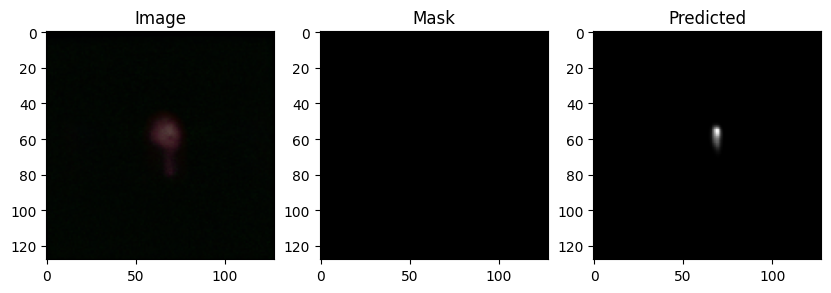

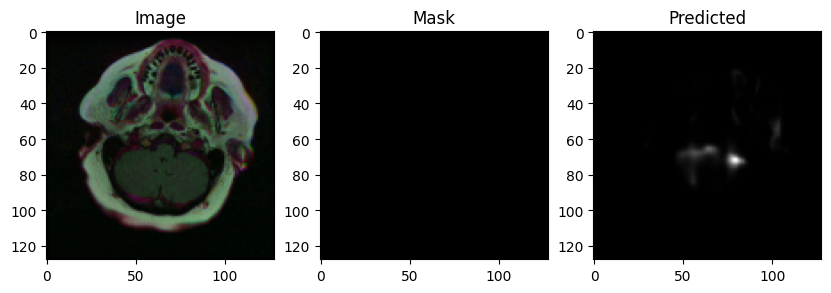

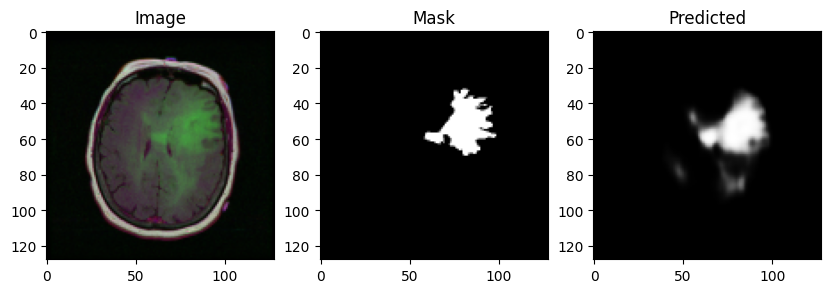

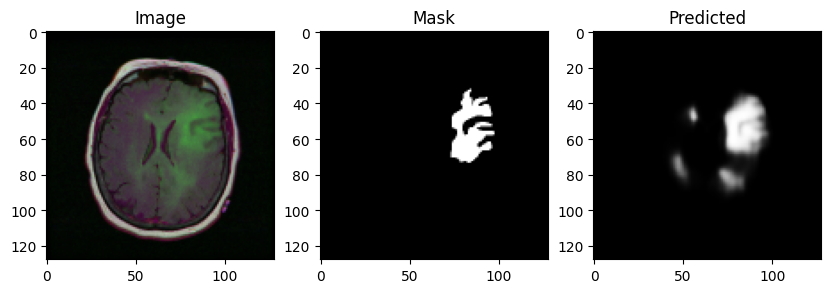

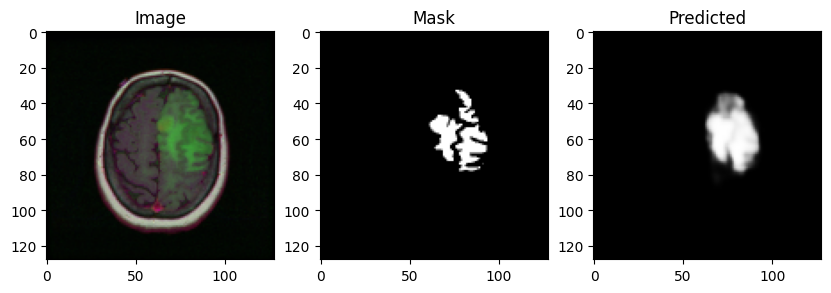

In [ ]:
import matplotlib.pyplot as plt
preds = model.predict(images[:5])

for i in range(5):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(images[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Mask")

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title("Predicted")

    plt.show()

In [ ]:
# ==============================
# TEST ON NEW MRI IMAGE
# ==============================

import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/MRI_of_Human_Brain.jpg/500px-MRI_of_Human_Brain.jpg"

img = cv2.imread(image_path)


if img is None:
    raise ValueError("Image not found. Check file path!")


img_resized = cv2.resize(img, (128,128))


img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_resized = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)


img_resized = img_resized / 255.0


img_input = np.reshape(img_resized, (1,128,128,3))

pred = model.predict(img_input)

# ==============================
# SHOW RESULTS
# ==============================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Input MRI")

plt.subplot(1,2,2)
plt.imshow(pred[0].squeeze(), cmap='gray')
plt.title("Predicted Tumor Mask")

plt.show()

ValueError: Image not found. Check file path!